<a href="https://colab.research.google.com/github/nds-najam/Chronos_Model_Comparison/blob/main/notebooks/02_chronos2_univariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Chronos-2 Environment

In [2]:
!pip install uv
!uv pip install -q chronos-forecasting
!uv pip install -q pandas matplotlib scikit-learn
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

from chronos import Chronos2Pipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

pipeline_c2 = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device,
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 70.8 MB/s eta 0:00:00
2.11.0+cpu
False
CPU


config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [4]:
series = df["OT"].astype(float)
prediction_length = 48

train = series[:-prediction_length]
test = series[-prediction_length:]

import torch

context = torch.tensor(
    train.values,
    dtype=torch.float32,
)

# forecast = pipeline_c2.predict(
#     context,
#     prediction_length=prediction_length,
# )

# import numpy as np

# prediction = forecast[0].median(dim=0).values.numpy()

In [5]:
import inspect

print(inspect.signature(pipeline_c2.predict))

(inputs: Union[torch.Tensor, numpy.ndarray, Sequence[torch.Tensor | numpy.ndarray], Sequence[Mapping[str, Union[torch.Tensor, numpy.ndarray, Mapping[str, torch.Tensor | numpy.ndarray]]]], Sequence[chronos.chronos2.preprocess.PreparedInput]], prediction_length: int | None = None, batch_size: int = 256, context_length: int | None = None, cross_learning: bool = False, limit_prediction_length: bool = False, **kwargs) -> list[torch.Tensor]


In [6]:
import time

start = time.perf_counter()

context_c2 = context.unsqueeze(0).unsqueeze(0)
print(context_c2.shape)

forecast_c2 = pipeline_c2.predict(
    inputs=context_c2,
    prediction_length=prediction_length,
)

c2_time = time.perf_counter() - start

print(f"Inference time: {c2_time:.3f} seconds")

torch.Size([1, 1, 17372])
Inference time: 2.876 seconds


In [7]:
print(type(forecast_c2))
print(len(forecast_c2))

print(type(forecast_c2[0]))
print(forecast_c2[0].shape)

<class 'list'>
1
<class 'torch.Tensor'>
torch.Size([1, 21, 48])


In [8]:
print(context_c2.shape)

torch.Size([1, 1, 17372])


In [9]:
print(df.columns)

Index(['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'], dtype='object')


In [10]:
chronos2_prediction = forecast_c2[0][0, -1, :].cpu().numpy()

In [11]:
chronos2_prediction

array([ 9.711242 ,  9.737641 ,  9.789198 ,  9.809565 ,  9.921976 ,
       10.027306 , 10.144016 , 10.273049 , 10.443447 , 10.548509 ,
       10.877752 , 11.16884  , 11.494293 , 11.647715 , 11.829876 ,
       11.966589 , 12.312762 , 12.724093 , 13.227659 , 13.696478 ,
       14.1867485, 13.81226  , 13.421259 , 13.202757 , 12.75446  ,
       12.297394 , 12.155548 , 12.090863 , 11.938597 , 11.929227 ,
       11.766442 , 11.806929 , 11.876355 , 11.894152 , 12.130513 ,
       12.38044  , 12.584617 , 12.942886 , 13.119624 , 13.408664 ,
       13.633915 , 14.126315 , 14.672649 , 15.260209 , 15.402388 ,
       15.426067 , 14.854013 , 14.273987 ], dtype=float32)

In [12]:
import pandas as pd

context_df = train.reset_index()

context_df.columns = ["timestamp", "target"]
context_df["item_id"] = "ETTh1"

context_df = context_df[
    ["item_id", "timestamp", "target"]
]

context_df.head()

,item_id,timestamp,target
0,ETTh1,0,30.531000
1,ETTh1,1,27.787001
2,ETTh1,2,27.787001
3,ETTh1,3,25.044001
4,ETTh1,4,21.948000


In [13]:
pred_df = pipeline_c2.predict_df(
    context_df,
    prediction_length=prediction_length,
    id_column="item_id",
    timestamp_column="timestamp",
    target="target",
)

In [14]:
pred_df.head()

print(pred_df.columns)

Index(['item_id', 'timestamp', 'target_name', 'predictions', '0.1', '0.2',
       '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9'],
      dtype='object')


In [15]:
chronos2_prediction = pred_df["0.5"].values

In [16]:
pred_df.head()

,item_id,timestamp,target_name,predictions,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,ETTh1,1970-01-01 00:00:00.000017372,target,8.809501,8.442902,8.590962,8.673107,8.745724,8.809501,8.882086,8.944891,9.026465,9.145219
1,ETTh1,1970-01-01 00:00:00.000017373,target,8.680782,8.212046,8.415474,8.526268,8.609635,8.680782,8.752255,8.828392,8.930624,9.109902
2,ETTh1,1970-01-01 00:00:00.000017374,target,8.584439,7.968938,8.236123,8.387209,8.494674,8.584439,8.678565,8.775671,8.898667,9.099704
3,ETTh1,1970-01-01 00:00:00.000017375,target,8.479341,7.751712,8.063986,8.249445,8.374681,8.479341,8.581397,8.698276,8.846330,9.072533
4,ETTh1,1970-01-01 00:00:00.000017376,target,8.375260,7.535429,7.873297,8.078807,8.236730,8.375260,8.510871,8.647365,8.817377,9.075294


In [17]:
chronos2_prediction = pred_df["predictions"].values

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def mase(train, actual, prediction):
    """
    Mean Absolute Scaled Error
    """
    naive = np.abs(np.diff(train)).mean()
    return np.mean(np.abs(actual - prediction)) / naive

actual = test.values

mae_c2 = mean_absolute_error(actual, chronos2_prediction)

rmse_c2 = np.sqrt(
    mean_squared_error(actual, chronos2_prediction)
)

mase_c2 = mase(
    train.values,
    actual,
    chronos2_prediction,
)

print(f"MAE : {mae_c2:.4f}")
print(f"RMSE: {rmse_c2:.4f}")
print(f"MASE: {mase_c2:.4f}")

MAE : 0.8971
RMSE: 1.1222
MASE: 1.4589


In [19]:
import matplotlib.pyplot as plt

def plot_forecast(
    history,
    actual,
    prediction,
    model_name,
    history_length=None,
):
    """
    ---Plot historical data, actual future values, and model forecast.

    Parameters
    ----------
    history : pd.Series
        Historical training data.
    actual : pd.Series
        Actual values in the forecast horizon.
    prediction : array-like
        Forecast values.
    model_name : str
        Name of the forecasting model.
    history_length : int, optional
        Number of historical observations to display.
        If None, uses 6 × forecast horizon.
    """

    if history_length is None:
        history_length = len(actual) * 6

    plt.figure(figsize=(15, 5))

    # Plot only the recent history
    plt.plot(
        history.index[-history_length:],
        history.values[-history_length:],
        label="History",
        linewidth=2,
    )

    # Actual values
    plt.plot(
        actual.index,
        actual.values,
        label="Actual",
        linewidth=2,
    )

    # Forecast
    plt.plot(
        actual.index,
        prediction,
        "--",
        linewidth=2,
        label=model_name,
    )

    # Forecast start
    plt.axvline(
        actual.index[0],
        color="black",
        linestyle=":",
        label="Forecast Start",
    )

    plt.title(f"{model_name} Forecast")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

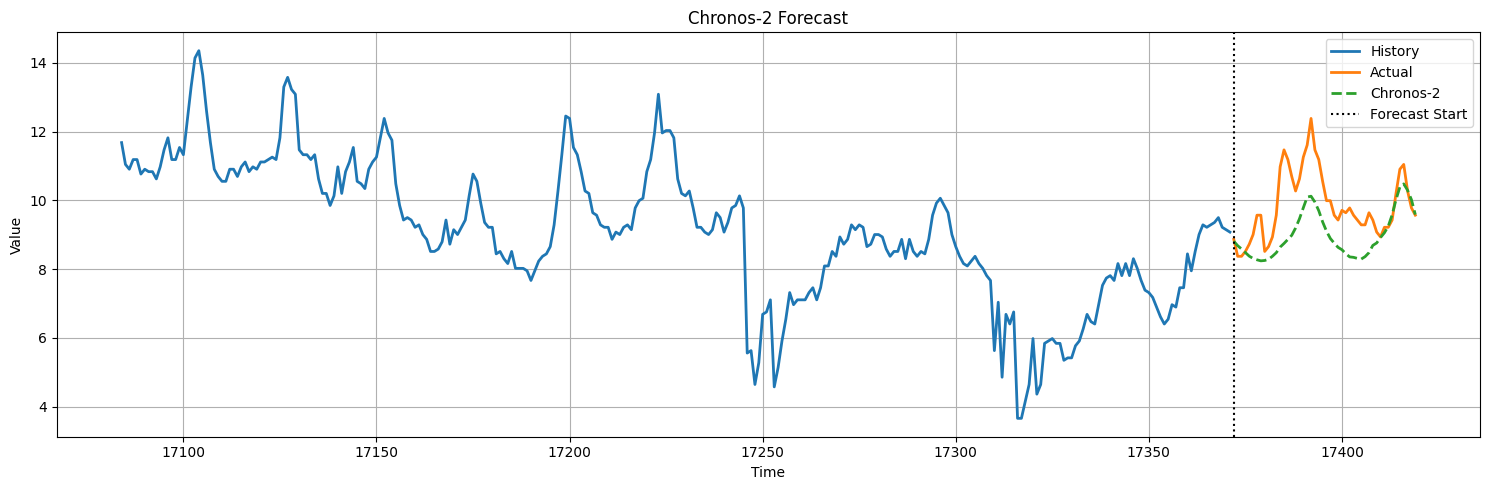

In [20]:
plot_forecast(
    train,
    test,
    chronos2_prediction,
    "Chronos-2",
)

In [21]:
leaderboard = pd.DataFrame({
    "Model": [
        # "Chronos-T5",
        "Chronos-2",
    ],
    "MASE": [
        # mase_t5,
        mase_c2,
    ],
    "MAE": [
        # mae_t5,
        mae_c2,
    ],
    "RMSE": [
        # rmse_t5,
        rmse_c2,
    ],
    "Inference Time (s)": [
        # t5_time,
        c2_time,
    ],
})

leaderboard = leaderboard.sort_values("MASE")
leaderboard

,Model,MASE,MAE,RMSE,Inference Time (s)
0,Chronos-2,1.458899,0.897085,1.122163,2.876286


In [22]:
import numpy as np

np.save(
    "/content/chronos2uni_forecast.npy",
    chronos2_prediction
)

np.save(
    "/content/chronos2uni_actual.npy",
    test
)

leaderboard.to_csv(
    "/content/Chronos2uni_leaderboard.csv",
    index=False
)


### Varying Context Lengths

In [1]:
!pip install uv
!uv pip install -q chronos-forecasting
!uv pip install -q pandas matplotlib scikit-learn
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

from chronos import Chronos2Pipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

pipeline_c2 = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device,
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 25.7 MB/s eta 0:00:00
2.11.0+cpu
False
CPU


config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def mase(train, actual, prediction):
    """
    Mean Absolute Scaled Error
    """
    naive = np.abs(np.diff(train)).mean()
    return np.mean(np.abs(actual - prediction)) / naive

In [6]:
import time
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch

series = df["OT"].astype(float)
prediction_length = 48

# Re-initialize the pipeline if it's missing from the kernel state
if 'pipeline_c2' not in globals():
    from chronos import Chronos2Pipeline
    device = "cuda" if torch.cuda.is_available() else "cpu"
    pipeline_c2 = Chronos2Pipeline.from_pretrained(
        "amazon/chronos-2",
        device_map=device,
    )

def mase(train, actual, prediction):
    """
    Mean Absolute Scaled Error
    """
    naive = np.abs(np.diff(train)).mean()
    return np.mean(np.abs(actual - prediction)) / naive

context_lengths = [512, 1024, 2048, 4096, 8192]
results = []

for cl in context_lengths:
    print(f"Evaluating context_length: {cl}")
    start = time.perf_counter()

    train = series[-(cl + prediction_length) :-prediction_length]
    test = series[-prediction_length:]

    context = torch.tensor(
    train.values,
    dtype=torch.float32,
    )

    context_df = train.reset_index()
    context_df.columns = ["timestamp", "target"]
    context_df["item_id"] = "ETTh1"
    context_df = context_df[
        ["item_id", "timestamp", "target"]
        ]

    # Generate predictions
    pred_df_cl = pipeline_c2.predict_df(
        context_df,
        prediction_length=prediction_length,
        id_column="item_id",
        timestamp_column="timestamp",
        target="target",
        context_length=cl
    )

    inf_time = time.perf_counter() - start

    # Extract prediction values
    actual = test.values
    pred_vals = pred_df_cl["predictions"].values

    # Calculate metrics
    mae = mean_absolute_error(actual, pred_vals)
    rmse = np.sqrt(mean_squared_error(actual, pred_vals))
    mase_val = mase(train.values, actual, pred_vals)

    # Append to results list
    results.append({
        "Model": f"Chronos-2 (ctx: {cl})",
        "Context Length": cl,
        "MASE": mase_val,
        "MAE": mae,
        "RMSE": rmse,
        "Inference Time (s)": inf_time
    })

# Create and display leaderboard
leaderboard_ctx = pd.DataFrame(results)
leaderboard_ctx = leaderboard_ctx.sort_values("MASE").reset_index(drop=True)
display(leaderboard_ctx)


Evaluating context_length: 512
Evaluating context_length: 1024
Evaluating context_length: 2048
Evaluating context_length: 4096
Evaluating context_length: 8192


,Model,Context Length,MASE,MAE,RMSE,Inference Time (s)
0,Chronos-2 (ctx: 8192),8192,1.878119,0.897085,1.122163,2.324609
1,Chronos-2 (ctx: 1024),1024,2.121218,0.864684,1.090183,0.425116
2,Chronos-2 (ctx: 2048),2048,2.127857,0.938562,1.159464,0.658141
3,Chronos-2 (ctx: 512),512,2.314311,0.899402,1.118141,0.283964
4,Chronos-2 (ctx: 4096),4096,2.445864,1.086926,1.291151,1.255584
